### 1. Fit the data to Bernoulli and Binomial distributions (transaction occurrence & weekly count).


Transaction Status:
transaction_status
Fail       122
Success     98
Name: count, dtype: int64

BERNOULLI DISTRIBUTION
Success Probability (p): 0.4455
Failure Probability (q): 0.5545

P(X = 0) - Failed: 0.5545
P(X = 1) - Success: 0.4455

BINOMIAL DISTRIBUTION
Number of Transactions (n): 10
Success Probability (p): 0.4455

Binomial Probabilities:
P(X = 0 ) = 0.0028
P(X = 1 ) = 0.0221
P(X = 2 ) = 0.0799
P(X = 3 ) = 0.1711
P(X = 4 ) = 0.2405
P(X = 5 ) = 0.2318
P(X = 6 ) = 0.1552
P(X = 7 ) = 0.0712
P(X = 8 ) = 0.0215
P(X = 9 ) = 0.0038
P(X = 10 ) = 0.0003

BINOMIAL STATISTICS
Mean: 4.4545
Variance: 2.4702

Probability of exactly 5 successful transactions: 0.2318



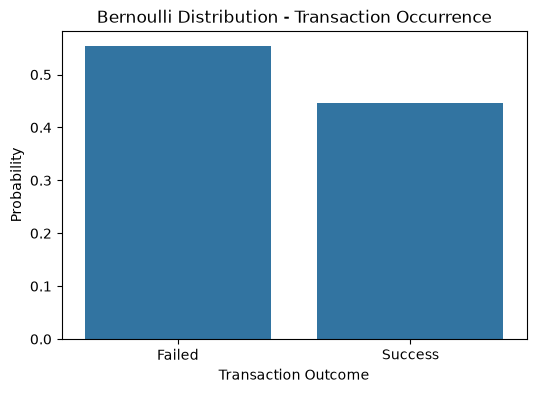

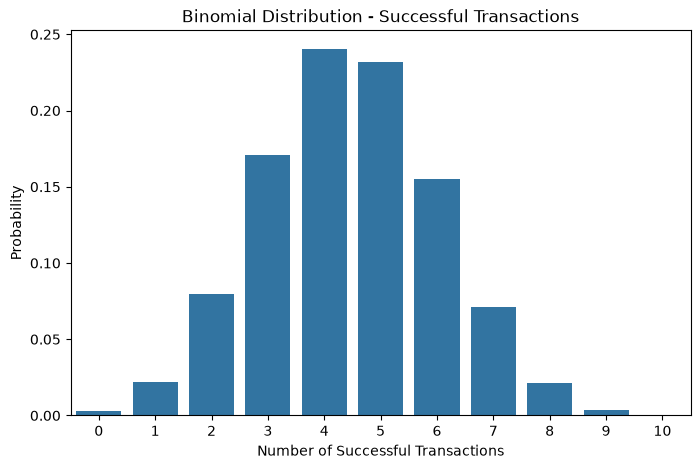

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import bernoulli, binom
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("spread_locator.csv")

# CHECK TRANSACTION STATUS
# ============================================================

print("Transaction Status:")
print(df["transaction_status"].value_counts())
print()

#   BERNOULLI DISTRIBUTION
# ============================================================
# Bernoulli distribution is used for ONE transaction.
#
# Success = 1
# Failure = 0
#
# Here:
# Successful Transaction = 1
# Failed Transaction = 0


df["success"] = np.where(
    df["transaction_status"].str.lower() == "success",
    1,
    0
)

# Probability of successful transaction
p = df["success"].mean()

# Probability of failed transaction
q = 1 - p

print("BERNOULLI DISTRIBUTION")
print("============================================================")

print("Success Probability (p):", round(p, 4))
print("Failure Probability (q):", round(q, 4))
print()

# Calculate Bernoulli probabilities
prob_0 = bernoulli.pmf(0, p)
prob_1 = bernoulli.pmf(1, p)

print("P(X = 0) - Failed:", round(prob_0, 4))
print("P(X = 1) - Success:", round(prob_1, 4))
print()

#  BINOMIAL DISTRIBUTION
# ============================================================
# Binomial distribution is used for MULTIPLE transactions.
#
# Example:
# Take 10 transactions.
#
# X = Number of successful transactions
#
# Possible values:
# 0, 1, 2, ..., 10


n = 10

# Possible number of successful transactions
x = np.arange(0, n + 1)

# Binomial probability
binomial_probability = binom.pmf(x, n, p)

print("BINOMIAL DISTRIBUTION")
print("============================================================")

print("Number of Transactions (n):", n)
print("Success Probability (p):", round(p, 4))
print()

print("Binomial Probabilities:")

for i in range(len(x)):
    print(
        "P(X =", x[i], ") =",
        round(binomial_probability[i], 4)
    )

print()

# BINOMIAL MEAN AND VARIANCE
# Mean = n × p
mean = n * p

# Variance = n × p × (1-p)
variance = n * p * (1 - p)

print("BINOMIAL STATISTICS")
print("============================================================")

print("Mean:", round(mean, 4))
print("Variance:", round(variance, 4))
print()

# PROBABILITY OF EXACTLY 5 SUCCESSFUL TRANSACTIONS

prob_exactly_5 = binom.pmf(5, n, p)

print("Probability of exactly 5 successful transactions:",
      round(prob_exactly_5, 4))

print()

# BERNOULLI PLOT

bernoulli_x = ["Failed", "Success"]
bernoulli_y = [prob_0, prob_1]

plt.figure(figsize=(6, 4))

sns.barplot(
    x=bernoulli_x,
    y=bernoulli_y
)

plt.title("Bernoulli Distribution - Transaction Occurrence")
plt.xlabel("Transaction Outcome")
plt.ylabel("Probability")

plt.show()

# BINOMIAL PLOT
plt.figure(figsize=(8, 5))

sns.barplot(
    x=x,
    y=binomial_probability
)

plt.title("Binomial Distribution - Successful Transactions")
plt.xlabel("Number of Successful Transactions")
plt.ylabel("Probability")

plt.show()

### 2.Fit the data to Poisson distribution (number of transactions per day).


Dataset Loaded Successfully!
Total Transactions: 220

Transaction Date Converted Successfully!

DAILY TRANSACTION COUNT
  transaction_date  transaction_count
0       2023-01-01                  6
1       2023-01-02                 12
2       2023-01-03                 10
3       2023-01-04                  7
4       2023-01-05                  9
5       2023-01-06                  6
6       2023-01-07                  7
7       2023-01-08                  5
8       2023-01-09                 10
9       2023-01-10                  8

POISSON PARAMETER
Average Transactions Per Day (lambda): 7.0968

POISSON PROBABILITIES
P(X = 0 ) = 0.0008
P(X = 1 ) = 0.0059
P(X = 2 ) = 0.0208
P(X = 3 ) = 0.0493
P(X = 4 ) = 0.0875
P(X = 5 ) = 0.1242
P(X = 6 ) = 0.1469
P(X = 7 ) = 0.1489
P(X = 8 ) = 0.1321
P(X = 9 ) = 0.1042
P(X = 10 ) = 0.0739
P(X = 11 ) = 0.0477
P(X = 12 ) = 0.0282

EXAMPLE PROBABILITIES
Probability of exactly 5 transactions: 0.1242
Probability of exactly 10 transactions: 0.0739

POISSON

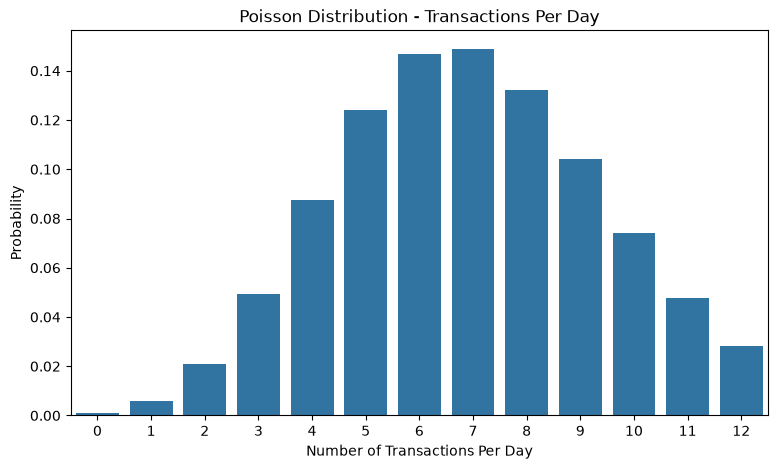

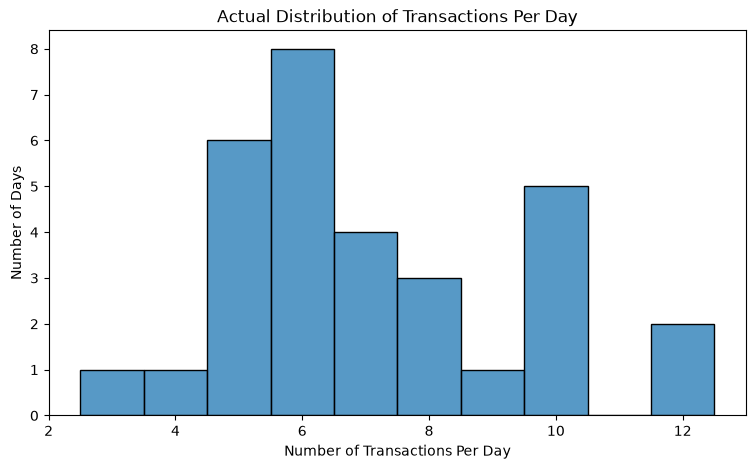

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("spread_locator.csv")

print("Dataset Loaded Successfully!")
print("Total Transactions:", len(df))
print()

# : CONVERT TRANSACTION DATE

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"]
)

print("Transaction Date Converted Successfully!")
print()

# STEP  COUNT TRANSACTIONS PER DAY
# Group all transactions by date.
#
# Example:
# 01-Jan -> 8 transactions
# 02-Jan -> 5 transactions
# 03-Jan -> 10 transactions


daily_transactions = (
    df.groupby(df["transaction_date"].dt.date)
      .size()
      .reset_index(name="transaction_count")
)

print("DAILY TRANSACTION COUNT")
print("============================================================")

print(daily_transactions.head(10))
print()

#  CALCULATE LAMBDA
# In Poisson distribution:
#
# lambda = Average number of events per time period
#
# Here:
# lambda = Average number of transactions per day


lambda_value = daily_transactions["transaction_count"].mean()

print("POISSON PARAMETER")
print("============================================================")

print(
    "Average Transactions Per Day (lambda):",
    round(lambda_value, 4)
)

print()

# POISSON PROBABILITY
# X = Number of transactions per day
#
# Calculate probability of:
# X = 0, 1, 2, 3, ... transactions


max_transactions = daily_transactions["transaction_count"].max()

x = np.arange(0, max_transactions + 1)

poisson_probability = poisson.pmf(
    x,
    lambda_value
)

print("POISSON PROBABILITIES")
print("============================================================")

for i in range(len(x)):
    print(
        "P(X =", x[i], ") =",
        round(poisson_probability[i], 4)
    )

print()

# EXAMPLE PROBABILITIES
# Probability of exactly 5 transactions in one day
prob_5 = poisson.pmf(5, lambda_value)

# Probability of exactly 10 transactions in one day
prob_10 = poisson.pmf(10, lambda_value)

print("EXAMPLE PROBABILITIES")
print("============================================================")

print(
    "Probability of exactly 5 transactions:",
    round(prob_5, 4)
)

print(
    "Probability of exactly 10 transactions:",
    round(prob_10, 4)
)

print()

# POISSON MEAN AND VARIANCE
# For Poisson distribution:
#
# Mean = lambda
# Variance = lambda

print("POISSON STATISTICS")
print("============================================================")

print(
    "Theoretical Mean:",
    round(lambda_value, 4)
)

print(
    "Theoretical Variance:",
    round(lambda_value, 4)
)

print()

#: ACTUAL DATA MEAN AND VARIANCE

actual_mean = daily_transactions["transaction_count"].mean()

actual_variance = daily_transactions[
    "transaction_count"
].var()

print("Actual Mean:", round(actual_mean, 4))
print("Actual Variance:", round(actual_variance, 4))
print()

# ACTUAL VS POISSON EXPECTED FREQUENCY

# Count how many days had each transaction count
actual_frequency = (
    daily_transactions["transaction_count"]
    .value_counts()
    .sort_index()
)

# Total number of days
total_days = len(daily_transactions)

# Expected frequency according to Poisson
expected_frequency = (
    poisson_probability * total_days
)

comparison = pd.DataFrame({
    "Transactions_Per_Day": x,
    "Actual_Days": [
        actual_frequency.get(i, 0)
        for i in x
    ],
    "Poisson_Expected_Days": expected_frequency
})


print("ACTUAL VS EXPECTED FREQUENCY")
print("============================================================")

print(comparison)
print()


# PLOT POISSON DISTRIBUTION

plt.figure(figsize=(9, 5))

sns.barplot(
    x=x,
    y=poisson_probability
)

plt.title(
    "Poisson Distribution - Transactions Per Day"
)

plt.xlabel("Number of Transactions Per Day")
plt.ylabel("Probability")

plt.show()

# ACTUAL TRANSACTION COUNT DISTRIBUTION

plt.figure(figsize=(9, 5))

sns.histplot(
    daily_transactions["transaction_count"],
    discrete=True,
    kde=False
)

plt.title(
    "Actual Distribution of Transactions Per Day"
)

plt.xlabel("Number of Transactions Per Day")
plt.ylabel("Number of Days")

plt.show()

### 3. Model transaction amounts using Log-Normal and Power Law distributions.


Dataset Loaded Successfully!
Total Transactions: 220

Valid Transaction Amounts: 220

Basic Statistics:
count      220.000000
mean      3365.192409
std       1985.705409
min        804.420000
25%       2124.205000
50%       3077.715000
75%       3950.737500
max      20462.840000
Name: transaction_amount, dtype: float64

LOG-NORMAL DISTRIBUTION
Shape parameter: 0.4749
Location parameter: 0
Scale parameter: 2983.1591

Log-Normal Mean: 3339.28
Log-Normal Standard Deviation: 1679.66

Log-Normal KS Statistic: 0.0378
Log-Normal p-value: 0.8999
Decision: Fail to Reject H0
Interpretation: Log-Normal distribution is reasonably
consistent with the data based on this test.

POWER LAW DISTRIBUTION
Power Law Shape (alpha-like parameter): 0.5193
Power Law Location: 0
Power Law Scale: 20462.84



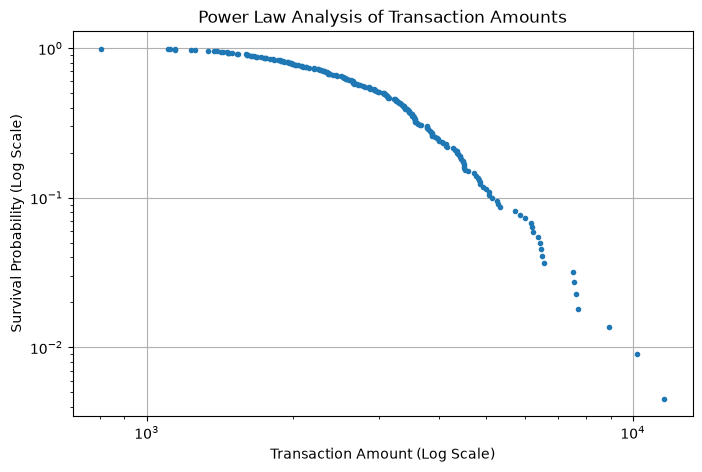

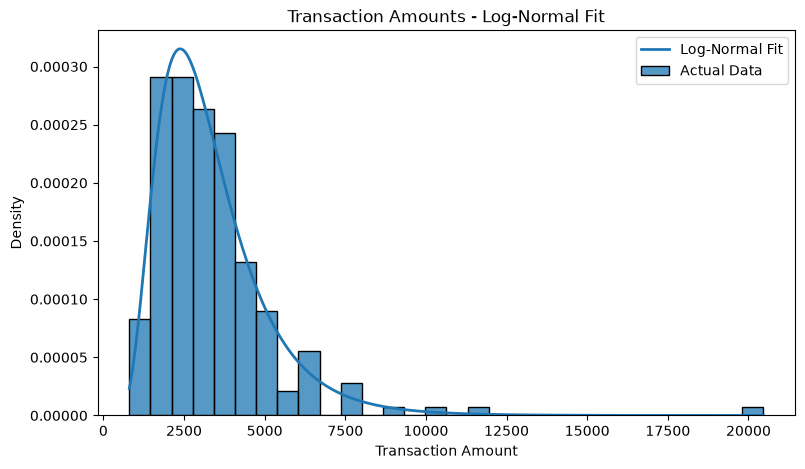

DISTRIBUTION COMPARISON
Log-Normal KS Statistic: 0.0378
Log-Normal p-value: 0.8999

Power Law fitted parameter: 0.5193

Note:
A smaller KS statistic generally indicates a closer
distributional fit, but the distributions should also
be evaluated based on their assumptions and data shape.


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: LOAD DATASET

# Change the filename if your CSV has a different name
df = pd.read_csv("spread_locator.csv")

print("Dataset Loaded Successfully!")
print("Total Transactions:", len(df))
print()

# : CLEAN TRANSACTION AMOUNT

# Remove missing values
amounts = df["transaction_amount"].dropna()

# Transaction amount must be positive
amounts = amounts[amounts > 0]

print("Valid Transaction Amounts:", len(amounts))
print()

print("Basic Statistics:")
print(amounts.describe())
print()

# STEP  LOG-NORMAL DISTRIBUTION
# Log-Normal distribution is useful when:
# - Data is positive
# - Data is right-skewed
# - A few transactions have very large amounts
#
# We fit the transaction_amount data to Log-Normal.


# Fit Log-Normal distribution
shape, loc, scale = stats.lognorm.fit(
    amounts,
    floc=0
)

# Calculate mean and standard deviation
lognormal_mean = stats.lognorm.mean(
    shape,
    loc=loc,
    scale=scale
)

lognormal_std = stats.lognorm.std(
    shape,
    loc=loc,
    scale=scale
)

print("LOG-NORMAL DISTRIBUTION")
print("============================================================")

print("Shape parameter:", round(shape, 4))
print("Location parameter:", round(loc, 4))
print("Scale parameter:", round(scale, 4))

print()

print("Log-Normal Mean:",
      round(lognormal_mean, 2))

print("Log-Normal Standard Deviation:",
      round(lognormal_std, 2))

print()

# LOG-NORMAL GOODNESS OF FIT
# Kolmogorov-Smirnov test checks how closely the
# actual data follows the fitted Log-Normal distribution.
#
# H0: Data follows the Log-Normal distribution
# H1: Data does not follow the Log-Normal distribution


ks_lognormal, p_lognormal = stats.kstest(
    amounts,
    "lognorm",
    args=(shape, loc, scale)
)

print("Log-Normal KS Statistic:",
      round(ks_lognormal, 4))

print("Log-Normal p-value:",
      round(p_lognormal, 4))

if p_lognormal >= 0.05:
    print("Decision: Fail to Reject H0")
    print("Interpretation: Log-Normal distribution is reasonably")
    print("consistent with the data based on this test.")
else:
    print("Decision: Reject H0")
    print("Interpretation: Data does not closely follow")
    print("the fitted Log-Normal distribution.")

print()

# POWER LAW DISTRIBUTION
# Power Law is useful for data where:
# - Most observations are relatively small
# - A small number of observations are extremely large
#
# Power Law:
# P(X) is proportional to X^(-alpha)
#
# Here we fit a Power Law to transaction amounts.


# Estimate Power Law parameters
power_shape, power_loc, power_scale = stats.powerlaw.fit(
    amounts,
    floc=0
)

print("POWER LAW DISTRIBUTION")
print("============================================================")

print("Power Law Shape (alpha-like parameter):",
      round(power_shape, 4))

print("Power Law Location:",
      round(power_loc, 4))

print("Power Law Scale:",
      round(power_scale, 4))

print()

# LOG-LOG ANALYSIS FOR POWER LAW
# Power Law relationships are often examined on a log-log plot.
#
# We create:
# X = Transaction Amount
# Y = Survival Probability


sorted_amounts = np.sort(amounts)

# Survival probability
survival_probability = (
    1 - np.arange(1, len(sorted_amounts) + 1)
    / len(sorted_amounts)
)

# Remove zero probabilities
mask = survival_probability > 0

x_power = sorted_amounts[mask]
y_power = survival_probability[mask]

# POWER LAW PLOT

plt.figure(figsize=(8, 5))

plt.loglog(
    x_power,
    y_power,
    marker="o",
    linestyle="none",
    markersize=3
)

plt.title("Power Law Analysis of Transaction Amounts")
plt.xlabel("Transaction Amount (Log Scale)")
plt.ylabel("Survival Probability (Log Scale)")

plt.grid(True)

plt.show()

# LOG-NORMAL HISTOGRAM + FITTED CURVE

plt.figure(figsize=(9, 5))

# Actual transaction amounts
sns.histplot(
    amounts,
    bins=30,
    stat="density",
    kde=False,
    label="Actual Data"
)

# Values for fitted curve
x_values = np.linspace(
    amounts.min(),
    amounts.max(),
    500
)

# Log-Normal PDF
lognormal_pdf = stats.lognorm.pdf(
    x_values,
    shape,
    loc=loc,
    scale=scale
)

plt.plot(
    x_values,
    lognormal_pdf,
    linewidth=2,
    label="Log-Normal Fit"
)

plt.title("Transaction Amounts - Log-Normal Fit")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.legend()

plt.show()

# COMPARE LOG-NORMAL AND POWER LAW

print("DISTRIBUTION COMPARISON")
print("============================================================")

print("Log-Normal KS Statistic:",
      round(ks_lognormal, 4))

print("Log-Normal p-value:",
      round(p_lognormal, 4))

print()

print("Power Law fitted parameter:",
      round(power_shape, 4))

print()

print("Note:")
print("A smaller KS statistic generally indicates a closer")
print("distributional fit, but the distributions should also")
print("be evaluated based on their assumptions and data shape.")

### 4. Generate and interpret a Q-Q Plot to test normality.


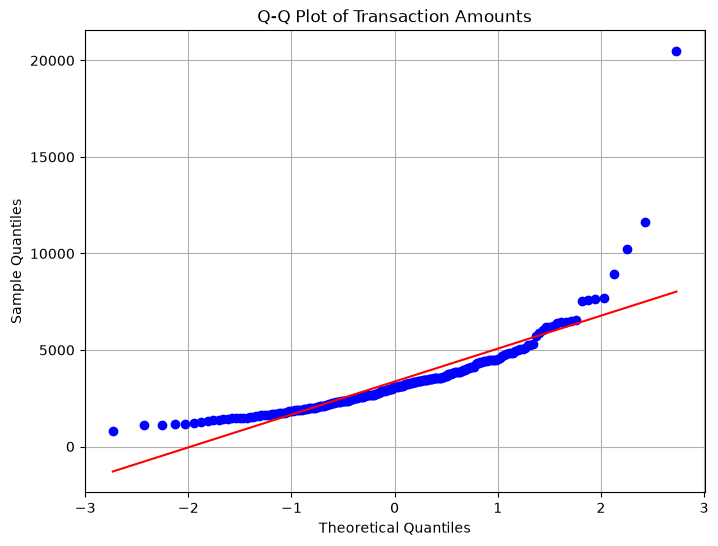

Shapiro-Wilk Test
--------------------------
Test Statistic : 0.7360905672029513
P-value        : 1.910419606632687e-18


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("spread_locator.csv")

# : Select transaction amount
# Remove missing values and zero/negative values
amounts = df["transaction_amount"].dropna()
amounts = amounts[amounts > 0]

# STEP  Generate Q-Q Plot
plt.figure(figsize=(8, 6))

stats.probplot(amounts, dist="norm", plot=plt)

plt.title("Q-Q Plot of Transaction Amounts")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)

plt.show()

# Perform Shapiro-Wilk Normality Test
# Shapiro test can be slow/limited for very large datasets,
# so we use a maximum sample of 5000 observations.
sample = amounts.sample(
    min(5000, len(amounts)),
    random_state=42
)

statistic, p_value = stats.shapiro(sample)

print("Shapiro-Wilk Test")
print("--------------------------")
print("Test Statistic :", statistic)
print("P-value        :", p_value)

### 5. Apply Box-Cox Transform to stabilize variance.


Box-Cox Transformation
------------------------------
Original Mean      : 3365.1924090909088
Original Variance  : 3943025.9719736218

Lambda (λ)          : -0.18083390743966327

Transformed Mean    : 4.223859127883152
Transformed Variance: 0.012326717461301531


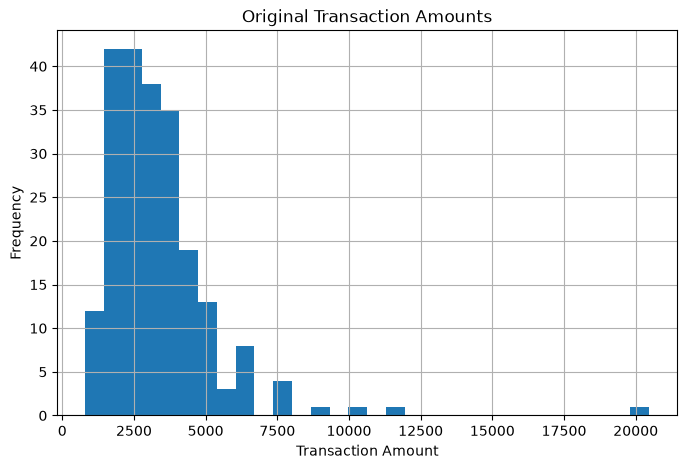

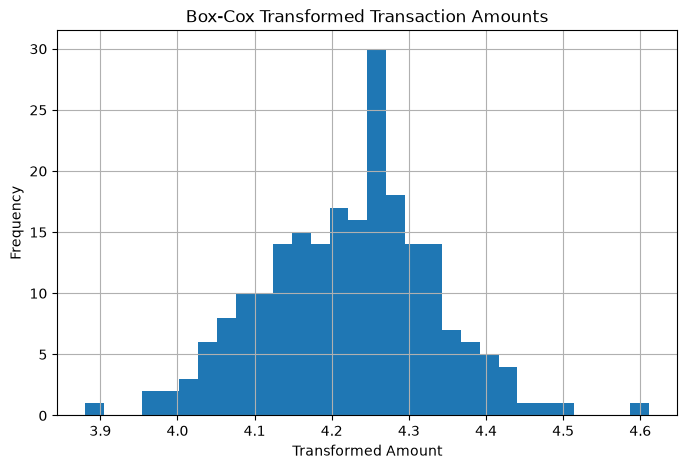

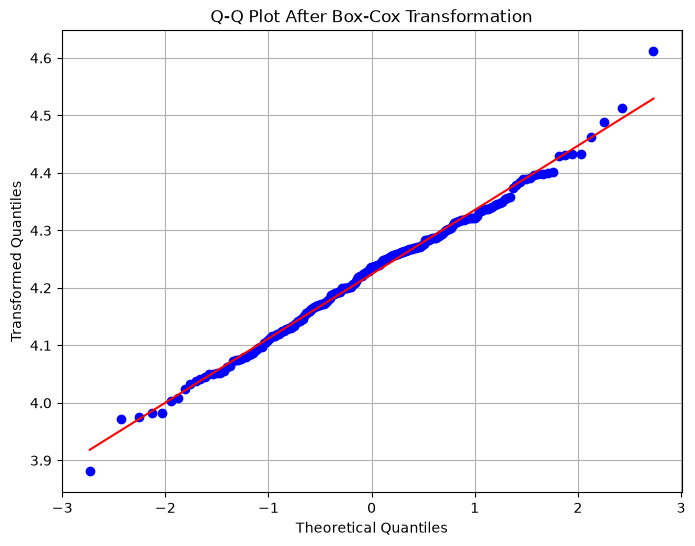

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("spread_locator.csv")

# : Select transaction amounts
# Box-Cox requires positive values
amounts = df["transaction_amount"].dropna()
amounts = amounts[amounts > 0]

# STEP  Apply Box-Cox Transformation
# scipy automatically finds the best lambda
transformed_amounts, lambda_value = stats.boxcox(amounts)

#  Display Lambda value
print("Box-Cox Transformation")
print("------------------------------")
print("Original Mean      :", amounts.mean())
print("Original Variance  :", amounts.var())

print("\nLambda (λ)          :", lambda_value)

print("\nTransformed Mean    :", transformed_amounts.mean())
print("Transformed Variance:", transformed_amounts.var())

# Plot Original vs Transformed Data
plt.figure(figsize=(8, 5))
plt.hist(amounts, bins=30)
plt.title("Original Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(transformed_amounts, bins=30)
plt.title("Box-Cox Transformed Transaction Amounts")
plt.xlabel("Transformed Amount")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Q-Q Plot after transformation
plt.figure(figsize=(8, 6))

stats.probplot(transformed_amounts, dist="norm", plot=plt)

plt.title("Q-Q Plot After Box-Cox Transformation")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Transformed Quantiles")
plt.grid(True)

plt.show()

### 6. Calculate Z-scores for transaction amounts and compute probability of transactions exceeding ₹5000.


Transaction Amount Statistics
--------------------------------
Mean               : 3365.1924090909088
Standard Deviation : 1985.705409161596

First 10 Z-Scores:
   transaction_amount   z_score
0             3821.34  0.229716
1             2781.84 -0.293776
2             4120.97  0.380609
3             6383.78  1.520159
4             2651.61 -0.359360
5             2651.63 -0.359350
6             6565.65  1.611748
7             4375.24  0.508659
8             2357.28 -0.507584
9             3909.95  0.274340

Z-score for ₹5000: 0.8232880785671723

Probability of transaction exceeding ₹5000:
0.20517209567554384

Probability in percentage:
20.517209567554385 %

Actual Dataset Probability:
0.11363636363636363

Actual Dataset Probability (%):
11.363636363636363 %


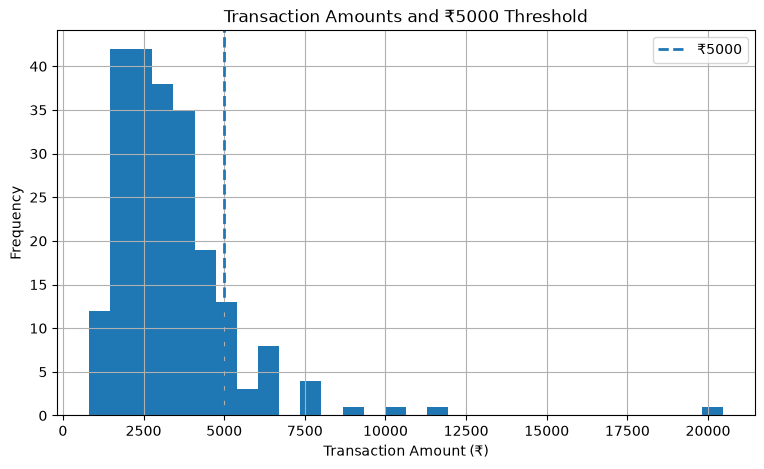

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("spread_locator.csv")

# : Select transaction amounts
# Remove missing and non-positive values
amounts = df["transaction_amount"].dropna()
amounts = amounts[amounts > 0]

# STEP  Calculate Mean and Standard Deviation
mean_amount = amounts.mean()
std_amount = amounts.std()

print("Transaction Amount Statistics")
print("--------------------------------")
print("Mean               :", mean_amount)
print("Standard Deviation :", std_amount)

# Calculate Z-Scores
# Formula:
# Z = (X - Mean) / Standard Deviation
df.loc[amounts.index, "z_score"] = (
    (amounts - mean_amount) / std_amount
)

# Display first 10 transactions
print("\nFirst 10 Z-Scores:")
print(df[["transaction_amount", "z_score"]].head(10))

# Calculate Z-score for ₹5000
z_5000 = (5000 - mean_amount) / std_amount

print("\nZ-score for ₹5000:", z_5000)

# Probability of transaction exceeding ₹5000
#
# P(X > 5000) = 1 - CDF(5000)
probability_exceed_5000 = 1 - stats.norm.cdf(
    5000,
    loc=mean_amount,
    scale=std_amount
)

print("\nProbability of transaction exceeding ₹5000:")
print(probability_exceed_5000)

print("\nProbability in percentage:")
print(probability_exceed_5000 * 100, "%")

# Empirical probability from actual dataset
actual_probability = (amounts > 5000).mean()

print("\nActual Dataset Probability:")
print(actual_probability)

print("\nActual Dataset Probability (%):")
print(actual_probability * 100, "%")

# Plot transaction amounts
plt.figure(figsize=(9, 5))

plt.hist(amounts, bins=30)

plt.axvline(
    5000,
    linestyle="--",
    linewidth=2,
    label="₹5000"
)

plt.title("Transaction Amounts and ₹5000 Threshold")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()  

### 7. Plot and interpret PDF and CDF for transaction amounts.


Transaction Amount Statistics
--------------------------------
Mean               : 3365.1924090909088
Standard Deviation : 1985.705409161596


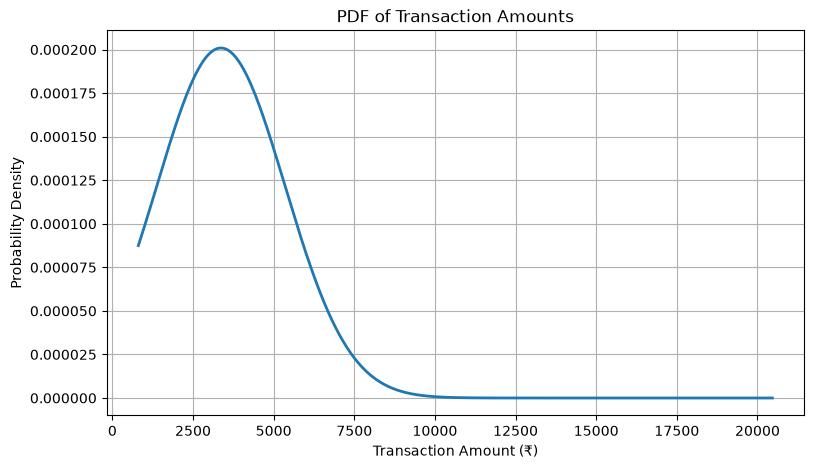

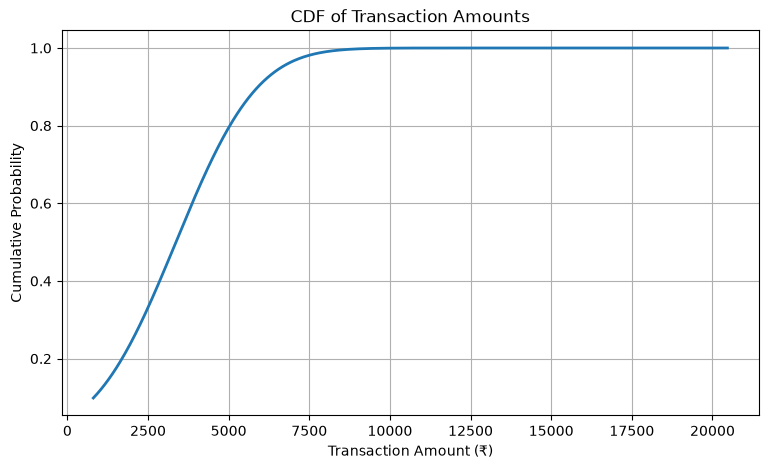


Probability Results
--------------------------------
P(Transaction <= ₹5000) : 0.7948279043244562
P(Transaction > ₹5000)  : 0.20517209567554384


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("spread_locator.csv")

# : Select transaction amounts
# Remove missing and non-positive values
amounts = df["transaction_amount"].dropna()
amounts = amounts[amounts > 0]

# STEP  Calculate Mean and Standard Deviation
mean_amount = amounts.mean()
std_amount = amounts.std()

print("Transaction Amount Statistics")
print("--------------------------------")
print("Mean               :", mean_amount)
print("Standard Deviation :", std_amount)

# Create X values for PDF and CDF
x = np.linspace(
    amounts.min(),
    amounts.max(),
    500
)

# Calculate PDF
# PDF = Probability Density Function
pdf = stats.norm.pdf(
    x,
    loc=mean_amount,
    scale=std_amount
)

# Calculate CDF
# CDF = Cumulative Distribution Function
cdf = stats.norm.cdf(
    x,
    loc=mean_amount,
    scale=std_amount
)

# Plot PDF
plt.figure(figsize=(9, 5))

plt.plot(x, pdf, linewidth=2)

plt.title("PDF of Transaction Amounts")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Probability Density")
plt.grid(True)

plt.show()

# Plot CDF
plt.figure(figsize=(9, 5))

plt.plot(x, cdf, linewidth=2)

plt.title("CDF of Transaction Amounts")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Cumulative Probability")
plt.grid(True)

plt.show()

# Example probability for ₹5000
probability_above_5000 = 1 - stats.norm.cdf(
    5000,
    loc=mean_amount,
    scale=std_amount
)

probability_below_5000 = stats.norm.cdf(
    5000,
    loc=mean_amount,
    scale=std_amount
)

print("\nProbability Results")
print("--------------------------------")
print("P(Transaction <= ₹5000) :",
      probability_below_5000)

print("P(Transaction > ₹5000)  :",
      probability_above_5000)

### 8. Conclude which distribution best fits the dataset and justify insights for decision-making.

## Conclusion

The **Log-Normal distribution** is suitable for transaction amounts because transaction values are positive and usually right-skewed. The **Poisson distribution** is useful for the number of transactions per day. These distributions help in identifying unusual transactions, estimating high-value transaction probabilities, detecting possible risks, and planning daily transaction activities.
